<a href="https://colab.research.google.com/github/AyleenSantander/PProj/blob/main/Final_Project_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project "Titanic Dataset" M.7
#Name: Ayleen Santander

#Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import requests
import time
import random
import csv
from  PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import re

# Part 1: Introduction to Data Types and Storage Methods
# Hands-On: Load the Titanic dataset (available at the bottom of this page) and explore different types of data.

In [ ]:
transatlantic = pd.read_csv('titanic.csv')
print(transatlantic.head())
print(transatlantic.info())
print(transatlantic.dtypes)

   pclass  survived                                             name     sex      age  sibsp  parch  ticket      fare  \
0     1.0       1.0                    Allen, Miss. Elisabeth Walton  female  29.0000    0.0    0.0   24160  211.3375   
1     1.0       1.0                   Allison, Master. Hudson Trevor    male   0.9167    1.0    2.0  113781  151.5500   
2     1.0       0.0                     Allison, Miss. Helen Loraine  female   2.0000    1.0    2.0  113781  151.5500   
3     1.0       0.0             Allison, Mr. Hudson Joshua Creighton    male  30.0000    1.0    2.0  113781  151.5500   
4     1.0       0.0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female  25.0000    1.0    2.0  113781  151.5500   

     cabin embarked boat   body                        home.dest  
0       B5        S    2    NaN                     St Louis, MO  
1  C22 C26        S   11    NaN  Montreal, PQ / Chesterville, ON  
2  C22 C26        S  NaN    NaN  Montreal, PQ / Chesterville, ON  
3  C2

# Part 2: Compare and Contrast Types of Data Sources
# Hands-On: Write Python code to read data from different sources.

In [ ]:
clone_transatlantic = transatlantic.copy()
clone_transatlantic.to_excel('clone_transatlantic.xlsx', index=False)
clone_transatlantic = pd.read_excel('clone_transatlantic.xlsx')
print(clone_transatlantic.head())

   pclass  survived                                             name     sex      age  sibsp  parch  ticket      fare  \
0       1         1                    Allen, Miss. Elisabeth Walton  female  29.0000      0      0   24160  211.3375   
1       1         1                   Allison, Master. Hudson Trevor    male   0.9167      1      2  113781  151.5500   
2       1         0                     Allison, Miss. Helen Loraine  female   2.0000      1      2  113781  151.5500   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male  30.0000      1      2  113781  151.5500   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female  25.0000      1      2  113781  151.5500   

     cabin embarked boat   body                        home.dest  
0       B5        S    2    NaN                     St Louis, MO  
1  C22 C26        S   11    NaN  Montreal, PQ / Chesterville, ON  
2  C22 C26        S  NaN    NaN  Montreal, PQ / Chesterville, ON  
3  C2

# Part 3: Structured vs. Unstructured Data
# Hands-On:Create examples of structured and unstructured data using Titanic Dataset
# structured_data.csv: Contains the structured data extracted from the Titanic dataset.
# unstructured_data.txt: Contains the unstructured data (names of passengers) and 3 pictures.

In [ ]:
#1.Structured data
structured = transatlantic[[ "name", "age", "sex", "embarked", "home.dest"]]
print("Structured Data:")
print(structured.head())

Structured Data:
                                              name      age     sex embarked                        home.dest
0                    Allen, Miss. Elisabeth Walton  29.0000  female        S                     St Louis, MO
1                   Allison, Master. Hudson Trevor   0.9167    male        S  Montreal, PQ / Chesterville, ON
2                     Allison, Miss. Helen Loraine   2.0000  female        S  Montreal, PQ / Chesterville, ON
3             Allison, Mr. Hudson Joshua Creighton  30.0000    male        S  Montreal, PQ / Chesterville, ON
4  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  25.0000  female        S  Montreal, PQ / Chesterville, ON


#2.Unstructured data
#1. Text unstructured



In [ ]:
unstructured = transatlantic.apply(lambda row: f"Passenger {row['name']} was a {row['age']} year old {row['sex']} " f"traveling in class {row['pclass']}. " f"{'Survived' if row['survived'] == 1 else 'Did not survive'}.", axis=1)

print("\nUNSTRUCTURED DATA:")
print(unstructured.head())
print(unstructured.info())


UNSTRUCTURED DATA:
0    Passenger Allen, Miss. Elisabeth Walton was a 29.0 year old female traveling...
1    Passenger Allison, Master. Hudson Trevor was a 0.9167 year old male travelin...
2    Passenger Allison, Miss. Helen Loraine was a 2.0 year old female traveling i...
3    Passenger Allison, Mr. Hudson Joshua Creighton was a 30.0 year old male trav...
4    Passenger Allison, Mrs. Hudson J C (Bessie Waldo Daniels) was a 25.0 year ol...
dtype: object
<class 'pandas.core.series.Series'>
RangeIndex: 1310 entries, 0 to 1309
Series name: None
Non-Null Count  Dtype 
--------------  ----- 
1310 non-null   object
dtypes: object(1)
memory usage: 10.4+ KB
None


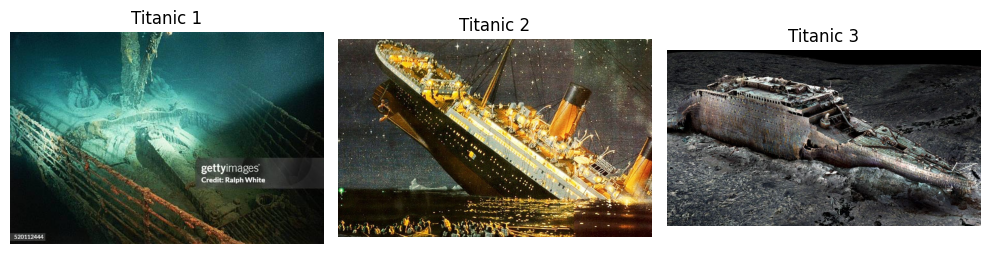

In [ ]:
#3. Image
#Load Image
Image1 = Image.open('Titanic_1.jpg')
Image2 = Image.open('Titanic_2.jpg')
Image3 = Image.open('Titanic_3.jpg')
#Display the images
fig, axes = plt.subplots(1,3, figsize=(10,5))
axes[0].imshow(Image1)
axes[0].axis('off')
axes[0].set_title('Titanic 1')

axes[1].imshow(Image2)
axes[1].axis('off')
axes[1].set_title('Titanic 2')

axes[2].imshow(Image3)
axes[2].axis('off')
axes[2].set_title('Titanic 3')
plt.tight_layout()
plt.show()


#Part 4: Storage Considerations
#Hands-On:Implement storage solutions in Python.

In [ ]:
data = {
    'StudentID': [1,2,3,4,5],
    'Name': ['Alice', 'Bob', 'Diana', 'Eve', 'Cleo'],
    'Course': ['Math', 'Science', 'Art', 'History', 'Music'],
    'Grade':       ['A', 'B', 'A', 'C', 'B'],
    'Score':       [95, 82, 91, 74, 88]
}

df = pd.DataFrame(data)
print(df.head())

# 1. Save as Excel
df.to_excel('students.xlsx', index=False)
print("Excel file saved: students.xlsx")

# 2. Save as CSV
df.to_csv('students.csv', index=False)
print("CSV file saved: students.csv")

# 3. Save as SQL Database
conn = sqlite3.connect('students.db')           # creates the database file
df.to_sql('students', conn,                     # 'students' is the table name
          if_exists='replace',                  # replace table if it already exists
          index=False)
conn.close()
print("SQL database saved: students.db")

#Verify: Read back all three files
print("\n Excel")
print(pd.read_excel('students.xlsx'))

print("\n CSV ")
print(pd.read_csv('students.csv'))

print("\n SQL")
conn = sqlite3.connect('students.db')
print(pd.read_sql('SELECT * FROM students', conn))
conn.close()

   StudentID   Name   Course Grade  Score
0          1  Alice     Math     A     95
1          2    Bob  Science     B     82
2          3  Diana      Art     A     91
3          4    Eve  History     C     74
4          5   Cleo    Music     B     88
Excel file saved: students.xlsx
CSV file saved: students.csv
SQL database saved: students.db

 Excel
   StudentID   Name   Course Grade  Score
0          1  Alice     Math     A     95
1          2    Bob  Science     B     82
2          3  Diana      Art     A     91
3          4    Eve  History     C     74
4          5   Cleo    Music     B     88

 CSV 
   StudentID   Name   Course Grade  Score
0          1  Alice     Math     A     95
1          2    Bob  Science     B     82
2          3  Diana      Art     A     91
3          4    Eve  History     C     74
4          5   Cleo    Music     B     88

 SQL
   StudentID   Name   Course Grade  Score
0          1  Alice     Math     A     95
1          2    Bob  Science     B     82
2   

# Part 5: Integrate and Use an API
# Hands-On:Fetch weather data for the departure (Southampton) and arrival (New York) locations of the Titanic.
#Step 2: Second Methors API Data Acquisition/ Accessing OpenWeather data and import library previous

In [ ]:
#My API Keys
api_key =  'f419a5dfd85013130cde8825389b4802'

#Define cities = Southampton and New York
city_1 = 'Southampton'
city_2 = 'New York'
url = 'https://api.openweathermap.org/data/2.5/weather'

#Obtain data from website
records =[]
for city in [city_1, city_2]:
    response = requests.get(url, params={'q': city, 'appid': api_key, 'units': 'metric'})

    if response.status_code == 200:
        data = response.json()
        print(f"City: {data['name']}")
        print(f"Temperature: {data['main']['temp']}°C")
        print(f"Humidity: {data['main']['humidity']}%")
        print(f"Weather: {data['weather'][0]['description']}")
        print('-' * 50)
    else:
        print(f"Error for {city}: {response.status_code} - {response.text}")

# Convert to DataFrame
records = []
for city in [city_1, city_2]:
    response = requests.get(url, params={'q': city, 'appid': api_key, 'units': 'metric'})
    if response.status_code == 200:
        data = response.json()
        records.append({
            'City': data['name'],
            'Temperature': data['main']['temp'],
            'Humidity': data['main']['humidity'],
            'Weather': data['weather'][0]['description']
        })
    else:
        print(f"Error for {city}: {response.status_code}")
df = pd.DataFrame(records)
print(f'Weather data departure Southampton and arrival New York:\n',df)

City: Southampton
Temperature: 13.97°C
Humidity: 79%
Weather: clear sky
--------------------------------------------------
City: New York
Temperature: 10.53°C
Humidity: 92%
Weather: mist
--------------------------------------------------
Weather data departure Southampton and arrival New York:
           City  Temperature  Humidity    Weather
0  Southampton        13.97        79  clear sky
1     New York        10.53        92       mist


# Part 6: Data Quality Dimensions
# Hands-On:Assess the quality of the Titanic dataset.

In [ ]:
#Step 1: Inspection dataset / Identify missing values
print('Missing Values:\n',clone_transatlantic.isnull().sum())

Missing Values:
 pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64


In [ ]:
# Step 2: Replace None/null with NaN
clone_transatlantic['age'] = clone_transatlantic['age'].replace('null', np.nan)
clone_transatlantic['age'] = clone_transatlantic['age'].replace('None', np.nan)

In [ ]:
# Step 3: Fill NaN with median
clone_transatlantic['age'] = clone_transatlantic['age'].fillna(clone_transatlantic['age'].median())

# Verify changes
print('Missing age values remaining:', clone_transatlantic['age'].isnull().sum())
print('Median age applied:           ', clone_transatlantic['age'].median())

Missing age values remaining: 0
Median age applied:            28.0


#Titanic Dataset - Data Quality Assessment

In [ ]:
print ("=" *50)
print ('TITANIC DATASSET - DATA QUALITY ASSESSMENT')
print ("=" *50)

TITANIC DATASSET - DATA QUALITY ASSESSMENT


In [ ]:
summary = {
'Total Entries': clone_transatlantic.shape[0],
'Missing Values': clone_transatlantic.isnull().sum().to_dict(),
'Unique Values': clone_transatlantic.nunique().to_dict(),
'Data Types': clone_transatlantic.dtypes.to_dict(),
'Year of Service Statistics': {
'Count': clone_transatlantic['fare'].count(),
'Unique': clone_transatlantic['fare'].nunique(),
'Mean': round( clone_transatlantic['fare'].mean(),2),
'Median': clone_transatlantic['fare'].median(),
'Min': clone_transatlantic['fare'].min(),
'Max': clone_transatlantic['fare'].max()
}
}

In [ ]:

# Display summary
for section, values in summary.items():
     print(f"\n{section}:")
     if isinstance(values, dict):
         for key, value in values.items():
            print(f"  {key}: {value}")
     else:
         print(f"  {values}")


Total Entries:
  1309

Missing Values:
  pclass: 0
  survived: 0
  name: 0
  sex: 0
  age: 0
  sibsp: 0
  parch: 0
  ticket: 0
  fare: 1
  cabin: 1014
  embarked: 2
  boat: 823
  body: 1188
  home.dest: 564

Unique Values:
  pclass: 3
  survived: 2
  name: 1307
  sex: 2
  age: 98
  sibsp: 7
  parch: 8
  ticket: 929
  fare: 281
  cabin: 186
  embarked: 3
  boat: 27
  body: 121
  home.dest: 369

Data Types:
  pclass: int64
  survived: int64
  name: object
  sex: object
  age: float64
  sibsp: int64
  parch: int64
  ticket: object
  fare: float64
  cabin: object
  embarked: object
  boat: object
  body: float64
  home.dest: object

Year of Service Statistics:
  Count: 1308
  Unique: 281
  Mean: 33.3
  Median: 14.4542
  Min: 0.0
  Max: 512.3292


#Final Assesment

In [ ]:
print('\n=== DATA QUALITY ASSESSMENT')


=== DATA QUALITY ASSESSMENT


#Step 1: Completness(missing Values)

In [ ]:
total_cells =clone_transatlantic.shape[0] * clone_transatlantic.shape[1]
missing_cells = clone_transatlantic.isnull().sum().sum()
completeness = ((total_cells - missing_cells) / total_cells) * 100
print(f"\nCompleteness: {completeness:.2f}%")
print(f"Total cells: {total_cells}")
print(f"Missing cells: {missing_cells}")


Completeness: 80.40%
Total cells: 18326
Missing cells: 3592


#Step 2: Missing per column

In [ ]:
print("\nMissing values per column:")
for col, count in clone_transatlantic.isnull().sum().items():
    pct = (count / len(clone_transatlantic)) * 100
    print(f"  {col}: {count} missing ({pct:.1f}%)")


Missing values per column:
  pclass: 0 missing (0.0%)
  survived: 0 missing (0.0%)
  name: 0 missing (0.0%)
  sex: 0 missing (0.0%)
  age: 0 missing (0.0%)
  sibsp: 0 missing (0.0%)
  parch: 0 missing (0.0%)
  ticket: 0 missing (0.0%)
  fare: 1 missing (0.1%)
  cabin: 1014 missing (77.5%)
  embarked: 2 missing (0.2%)
  boat: 823 missing (62.9%)
  body: 1188 missing (90.8%)
  home.dest: 564 missing (43.1%)


#Step 3: Invalid values

In [ ]:
print("\n 2. Accuracy: Outliers & Valid Ranges")
print(clone_transatlantic[['age', 'fare', 'sibsp', 'parch']].describe())

print(f"\nNegative Fares:      {(clone_transatlantic['fare'] < 0).sum()}")
print(f"Age below 0:         {(clone_transatlantic['age'] < 0).sum()}")
print(f"Age above 100:       {(clone_transatlantic['age'] > 100).sum()}")
print(f"Invalid Pclass:      {(clone_transatlantic['pclass'].isin([1, 2, 3])).sum()}")
print(f"Invalid Survived:    {(clone_transatlantic['survived'].isin([0, 1])).sum()}")


 2. Accuracy: Outliers & Valid Ranges
               age         fare        sibsp        parch
count  1309.000000  1308.000000  1309.000000  1309.000000
mean     29.503183    33.295479     0.498854     0.385027
std      12.905246    51.758668     1.041658     0.865560
min       0.166700     0.000000     0.000000     0.000000
25%      22.000000     7.895800     0.000000     0.000000
50%      28.000000    14.454200     0.000000     0.000000
75%      35.000000    31.275000     1.000000     0.000000
max      80.000000   512.329200     8.000000     9.000000

Negative Fares:      0
Age below 0:         0
Age above 100:       0
Invalid Pclass:      1309
Invalid Survived:    1309


# 3. Consistency (duplicates, data types)

In [ ]:
print("\n 3. Consistency: Duplicates & Data Types ")
print(f"Duplicate rows:      {clone_transatlantic.duplicated().sum()}")
print(f"\nData Types:\n{clone_transatlantic.dtypes}")
print(f"\nUnique values in 'Sex':      {clone_transatlantic['sex'].unique()}")
print(f"Unique values in 'Embarked': {clone_transatlantic['embarked'].unique()}")
print(f"Unique values in 'Pclass':   {clone_transatlantic['pclass'].unique()}")


 3. Consistency: Duplicates & Data Types 
Duplicate rows:      0

Data Types:
pclass         int64
survived       int64
name          object
sex           object
age          float64
sibsp          int64
parch          int64
ticket        object
fare         float64
cabin         object
embarked      object
boat          object
body         float64
home.dest     object
dtype: object

Unique values in 'Sex':      ['female' 'male']
Unique values in 'Embarked': ['S' 'C' nan 'Q']
Unique values in 'Pclass':   [1 2 3]


#4. Timeliness

In [ ]:
print("\n 4. Timeliness")
print("The Titanic dataset is a historical snapshot from 1912.")
print("No date columns are present — timeliness is not applicable.")


 4. Timeliness
The Titanic dataset is a historical snapshot from 1912.
No date columns are present — timeliness is not applicable.


#Summary

In [ ]:
print("\n  Summary ")
print(f"Total Rows:          {len(clone_transatlantic)}")
print(f"Total Columns:       {len(clone_transatlantic.columns)}")
print(f"Duplicate Rows:      {clone_transatlantic.duplicated().sum()}")
print(f"Columns with nulls:  {(clone_transatlantic.isnull().sum() > 0).sum()}")
print(f"Total Missing Cells: {clone_transatlantic.isnull().sum().sum()}")


  Summary 
Total Rows:          1309
Total Columns:       14
Duplicate Rows:      0
Columns with nulls:  6
Total Missing Cells: 3592


# Part 7: Data Modeling
# Hands-On:Create a simple data model for a Hotel Management System. Completed in Lucichart

# Part 8: Data Visualization
# Hands-On:Create visualizations using matplotlib and seaborn.
# 1. Sales Distribution by Age

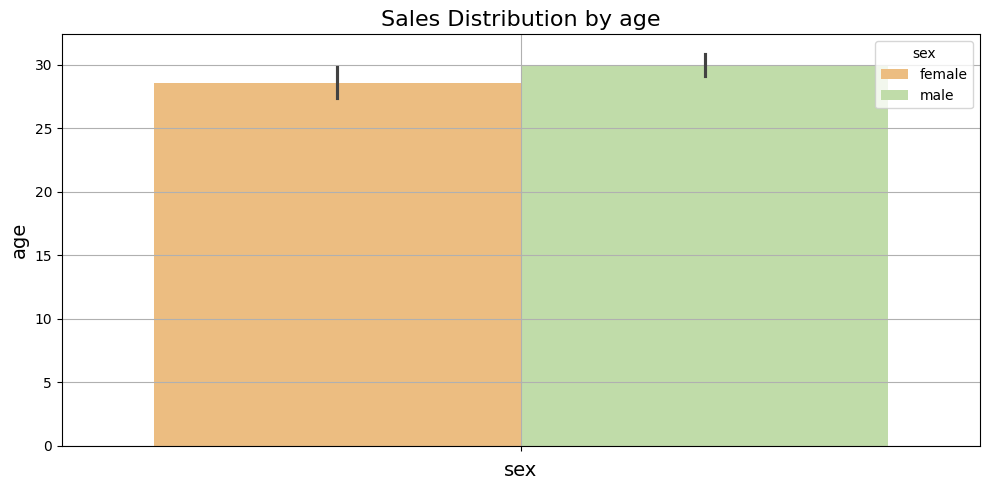

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data = clone_transatlantic, hue = 'sex',y = 'age',palette = 'Spectral',legend = 'auto',estimator = 'mean')
plt.title('Sales Distribution by age', fontsize= 16)
plt.xlabel('sex', fontsize= 14)
plt.ylabel('age', fontsize= 14)
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()


# 2. Total Distribution by Fare

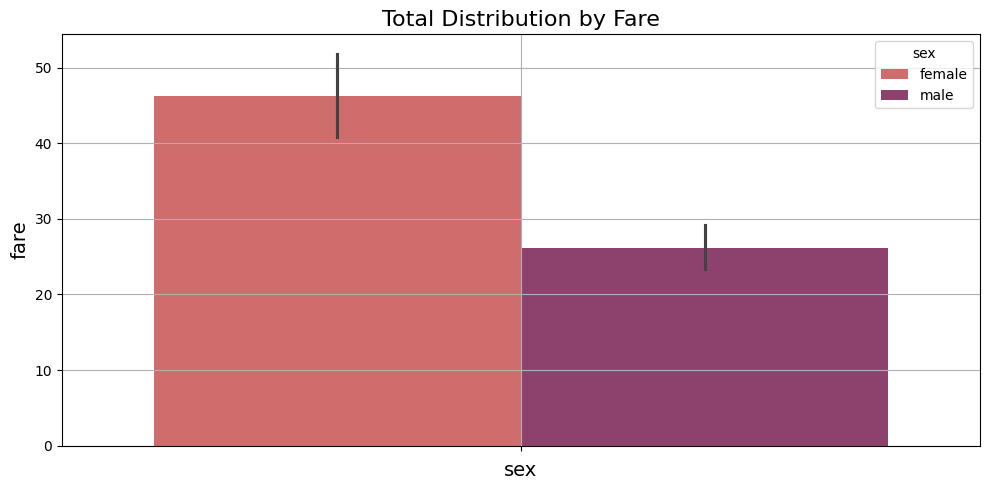

In [ ]:

plt.figure(figsize=(10, 5))
sns.barplot(data = clone_transatlantic, hue = 'sex',y = 'fare',palette = 'flare',legend = 'auto',estimator = 'mean')
plt.title('Total Distribution by Fare', fontsize= 16)
plt.xlabel('sex', fontsize= 14)
plt.ylabel('fare', fontsize= 14)
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()


# Part 9: Web Scraping
# Hands-On:Scrape additional data related to the Titanic from a website.
#Step 1: First Methods Web Scraping

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import json

# Part 1: Send HTTP Request
url = "https://en.wikipedia.org/wiki/Wreck_of_the_Titanic"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36'}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')

#Check what divs are available
print('Divs found:', len(soup.find_all('div')))

#Try finding paragraphs directly without the parent div
paragraphs = soup.find_all('p')
print(f'Total p tags found: {len(paragraphs)}')

#print first 3 raw to confirm content
for i, p in enumerate(paragraphs[:3]):
    print(f'\n Paragrap{1+1}')
    print(p.text.strip())
#Store non-empty paragraphs
data = []
for p in paragraphs:
    text = p.text.strip()
    if text:
        data.append({'Paragraph': text})
    if len(data) == 5:
      break
df = pd.DataFrame(data, columns=['Paragraph'])
print(f'\nTotal paragraphs scraped: {len(df)}')


# Clean citations
df['Paragraph'] = df['Paragraph'].str.replace(r'\[\d+\]', '', regex=True)
df['Paragraph'] = df['Paragraph'].str.replace(r'\s+', ' ', regex=True)
print(df)

df.to_csv('titanic_wiki.csv', index=False)
print("Saved to titanic_wiki.csv")



Divs found: 276
Total p tags found: 98

 Paragrap2
This is an accepted version of this page

 Paragrap2


 Paragrap2


Total paragraphs scraped: 5
                                                                         Paragraph
0                                         This is an accepted version of this page
1  The wreck of the British ocean liner, RMS Titanic, lies at a depth of about ...
2  The Titanic sank on 15 April 1912, after striking an iceberg during her maid...
3  Controversial salvage operations have recovered thousands of items, many of ...
4  Almost immediately after the Titanic sank on 15 April 1912, proposals were a...
Saved to titanic_wiki.csv


#Part 2: Transform to JSON

In [ ]:
json_data = df.to_json(orient='records', indent=4)
print("\n === JSON Output ===")
print(json_data)


 === JSON Output ===
[
    {
        "Paragraph":"This is an accepted version of this page"
    },
    {
        "Paragraph":"The wreck of the British ocean liner, RMS Titanic, lies at a depth of about 12,500 feet (2,100 fathoms; 3,800 metres), about 325 nautical miles (370 miles; 600 kilometres) south-southeast off the coast of Newfoundland, Canada. It lies in two main pieces about 2,000 feet (600 m) apart. The bow is still recognisable with many preserved interiors, despite deterioration and damage sustained by hitting the sea floor; in contrast, the stern is heavily damaged. The debris field around the wreck contains hundreds of thousands of items spilled from the ship as she sank."
    },
    {
        "Paragraph":"The Titanic sank on 15 April 1912, after striking an iceberg during her maiden voyage. Numerous expeditions unsuccessfully tried using sonar to map the seabed in the hope of finding the wreckage. In 1985, the wreck was located by a joint French\u2013American expedition 

#Part 3: Parse (Transform) JSON back to DataFrame

In [ ]:
# Parse JSON back to DataFrame
json_parsed = json.loads(json_data)
df_from_json = pd.DataFrame(json_parsed)

# Add columns
df_from_json.insert(0, 'Paragraph_ID', range(1, len(df_from_json) + 1))  # add ID column
df_from_json['Source'] = 'Wikipedia'                                       # add Source column
df_from_json['URL'] = url                                                  # add URL column

print("=== DataFrame from JSON ===")
print(df_from_json.to_string())                                            # shows full text

=== DataFrame from JSON ===
   Paragraph_ID                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

#Part 4: Transform DataFrame to readable

In [ ]:
# Wrap paragraph text for readable display
pd.set_option('display.max_colwidth', 80)       # limit column width to 80 chars
pd.set_option('display.width', 120)             #total display width

# Shorten URL for display
df_from_json['URL'] = 'wikipedia.org/Wreck_Titanic'  # shorter for readability

# Truncate paragraph for display only
df_display = df_from_json.copy()
df_display['Paragraph'] = df_display['Paragraph'].str[:100] + '...'  # first 100 chars

print("=== DataFrame (Readable) ===")
print(df_display.to_string(index=False))

=== DataFrame (Readable) ===
 Paragraph_ID                                                                                               Paragraph    Source                         URL
            1                                                             This is an accepted version of this page... Wikipedia wikipedia.org/Wreck_Titanic
            2 The wreck of the British ocean liner, RMS Titanic, lies at a depth of about 12,500 feet (2,100 fatho... Wikipedia wikipedia.org/Wreck_Titanic
            3 The Titanic sank on 15 April 1912, after striking an iceberg during her maiden voyage. Numerous expe... Wikipedia wikipedia.org/Wreck_Titanic
            4 Controversial salvage operations have recovered thousands of items, many of which have been conserve... Wikipedia wikipedia.org/Wreck_Titanic
            5 Almost immediately after the Titanic sank on 15 April 1912, proposals were advanced to salvage it fr... Wikipedia wikipedia.org/Wreck_Titanic
